<a href="https://colab.research.google.com/github/jenyabydaev-web/homeworkk/blob/homework/%220403_Self%20HomeWork%20scrapping%20books%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

# 기본 URL
base_url = "http://books.toscrape.com/"

In [4]:
res = requests.get(base_url)
soup = BeautifulSoup(res.text, 'html.parser')

# h3 태그 안의 a 태그에서 title 속성 가져오기
books_20 = []
for h3 in soup.select('h3'):
    title = h3.find('a')['title']
    books_20.append(title)

# 데이터프레임 변환
df_20 = pd.DataFrame(books_20, columns=['Title'])
print(df_20.head())

                                   Title
0                   A Light in the Attic
1                     Tipping the Velvet
2                             Soumission
3                          Sharp Objects
4  Sapiens: A Brief History of Humankind


In [5]:
books_100 = []
for i in range(1, 6): # 1~5페이지
    page_url = f"{base_url}catalogue/page-{i}.html"
    res = requests.get(page_url)
    soup = BeautifulSoup(res.text, 'html.parser')

    for h3 in soup.select('h3'):
        books_100.append(h3.find('a')['title'])

df_100 = pd.DataFrame(books_100, columns=['Title'])

In [7]:
categories = ['Travel', 'Mystery', 'Historical Fiction', 'Sequential Art', 'Classics',
              'Philosophy', 'Romance', 'Womens Fiction', 'Fiction', 'Childrens']

all_category_books = []

for cat in categories:
    # 카테고리별 URL 규칙에 맞춰 접속 (실제 사이트 구조에 따라 슬러그 처리가 필요할 수 있음)
    # 예시: travel_2, mystery_3 형태
    cat_url = f"{base_url}catalogue/category/books/{cat.lower().replace(' ', '-')}_{categories.index(cat)+2}/index.html"
    res = requests.get(cat_url)
    soup = BeautifulSoup(res.text, 'html.parser')

    products = soup.select('.product_pod')[:10] # 각 카테고리 상위 10개

    for product in products:
        title = product.select_one('h3 a')['title']
        price_text = product.select_one('.price_color').text # 예: £51.77
        price_numeric = float(price_text.replace('Â£', '')) # Modified line to handle 'Â£' symbol

        all_category_books.append({
            'Category': cat,
            'Title': title,
            'Price': price_text,
            'Price_Numeric': price_numeric
        })

df_books_dataset = pd.DataFrame(all_category_books)

# 가장 비싼 책 10개 제시
top_10_expensive = df_books_dataset.sort_values(by='Price_Numeric', ascending=False).head(10)
print(top_10_expensive)

              Category                                              Title  \
46            Classics                                            Candide   
51          Philosophy       The Death of Humanity: and the Case for Life   
93           Childrens  The White Cat and the Monk: A Retelling of the...   
70      Womens Fiction  I Had a Nice Time And Other Lies...: How to fi...   
47            Classics                                        Animal Farm   
7               Travel                   A Year in Provence (Provence #1)   
12             Mystery                                The Past Never Ends   
92           Childrens                    The Secret of Dreadwillow Carse   
66             Romance                   Suddenly in Love (Lake Haven #1)   
22  Historical Fiction            A Flight of Arrows (The Pathfinders #2)   

      Price  Price_Numeric  
46  Â£58.63          58.63  
51  Â£58.11          58.11  
93  Â£58.08          58.08  
70  Â£57.36          57.36  
47  Â£5

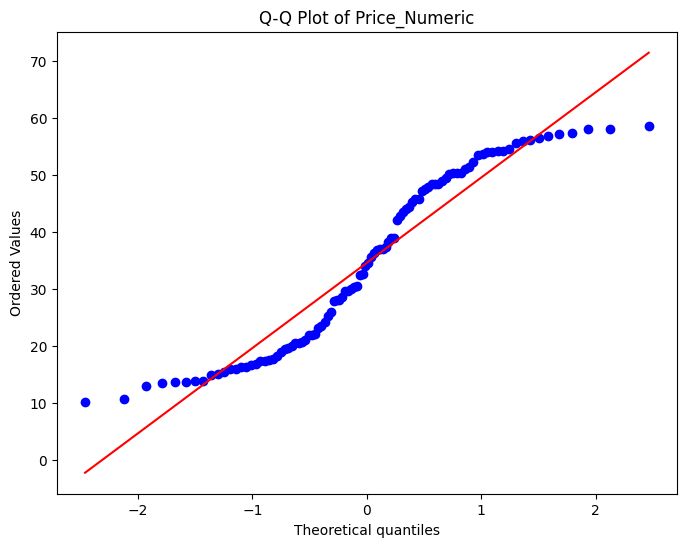

Shapiro-Wilk Test: Statistics=0.9158, p-value=0.0000
p-value <= 0.05 이므로 정규분포를 따른다는 귀무가설을 기각합니다 (정규성 위배).


In [8]:
# 1. Q-Q Plot 시각화
plt.figure(figsize=(8, 6))
stats.probplot(df_books_dataset['Price_Numeric'], dist="norm", plot=plt)
plt.title("Q-Q Plot of Price_Numeric")
plt.show()

# 2. Shapiro-Wilk Test (정규성 검정)
shapiro_test = stats.shapiro(df_books_dataset['Price_Numeric'])
print(f"Shapiro-Wilk Test: Statistics={shapiro_test.statistic:.4f}, p-value={shapiro_test.pvalue:.4f}")

# 해석 출력
if shapiro_test.pvalue > 0.05:
    print("p-value > 0.05 이므로 정규분포를 따른다는 귀무가설을 기각할 수 없습니다 (정규성 만족).")
else:
    print("p-value <= 0.05 이므로 정규분포를 따른다는 귀무가설을 기각합니다 (정규성 위배).")